<a href="https://colab.research.google.com/github/dindaaldiankhaira/digital_library/blob/main/praktikum_bab_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [6]:
from google.colab import files
uploaded = files.upload()

Saving praktikum bab 5.zip to praktikum bab 5.zip


In [9]:
import zipfile

zip_ref = zipfile.ZipFile('/content/praktikum bab 5.zip', 'r')
zip_ref.extractall('/content/')
zip_ref.close()

print("ZIP berhasil di extract")

ZIP berhasil di extract


In [10]:
import os
print(os.listdir('/content'))

['.config', '.ipynb_checkpoints', 'Didot', 'arial', 'Consolas', 'praktikum bab 5.zip', 'brandish', 'sample_data']


In [16]:
arial_path = '/content/arial'
consolas_path = '/content/Consolas'
didot_path = '/content/Didot'

In [17]:
import os

# Path folder dataset
arial_path = '/content/arial'
consolas_path = '/content/Consolas'
didot_path = '/content/Didot'

# Membaca isi folder
arial_filenames = os.listdir(arial_path)
consolas_filenames = os.listdir(consolas_path)
didot_filenames = os.listdir(didot_path)

# Menampilkan jumlah gambar
print("Arial :", len(arial_filenames))
print("Consolas :", len(consolas_filenames))
print("Didot :", len(didot_filenames))

Arial : 1
Consolas : 1
Didot : 1


In [18]:
import cv2
import numpy as np

data = []
labels = []

# Ukuran gambar
img_size = 64

# Fungsi load gambar
def load_images(path, label):
    for img_name in os.listdir(path):
        img_path = os.path.join(path, img_name)

        img = cv2.imread(img_path)

        if img is not None:
            img = cv2.resize(img, (img_size, img_size))
            data.append(img)
            labels.append(label)

# Load dataset
load_images(arial_path, 0)
load_images(consolas_path, 1)
load_images(didot_path, 2)

# Ubah ke array numpy
data = np.array(data)
labels = np.array(labels)

print("Jumlah data:", len(data))
print("Shape data:", data.shape)

Jumlah data: 3
Shape data: (3, 64, 64, 3)


In [19]:
from sklearn.model_selection import train_test_split

# Normalisasi gambar
data = data / 255.0

# Membagi data
X_train, X_test, y_train, y_test = train_test_split(
    data,
    labels,
    test_size=0.2,
    random_state=42
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 2
Test : 1


In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

# Model CNN
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(64,64,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(3, activation='softmax'))

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Ringkasan model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,539 (6.20 MB)

 Trainable params: 1,625,539 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.0000e+00 - loss: 1.3256 - val_accuracy: 0.0000e+00 - val_loss: 4.8195
Epoch 2/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.5000 - loss: 0.6977 - val_accuracy: 0.0000e+00 - val_loss: 6.3992
Epoch 3/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.5000 - loss: 0.7322 - val_accuracy: 0.0000e+00 - val_loss: 7.0311
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 1.0000 - loss: 0.5274 - val_accuracy: 0.0000e+00 - val_loss: 7.7248
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5000 - loss: 0.5460 - val_accuracy: 0.0000e+00 - val_loss: 7.5972
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 1.0000 - loss: 0.3733 - val_accuracy: 0.0000e+00 - val_loss: 7.7824
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 1.0000 - loss: 0.3391 - val_accuracy: 0.0000e+00 - val_loss: 8.3433
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 1.0000 - loss: 0.2239 - val

In [22]:
# Evaluasi model
loss, accuracy = model.evaluate(X_test, y_test)

print("Loss :", loss)
print("Accuracy :", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.0000e+00 - loss: 10.6096
Loss : 10.609583854675293
Accuracy : 0.0


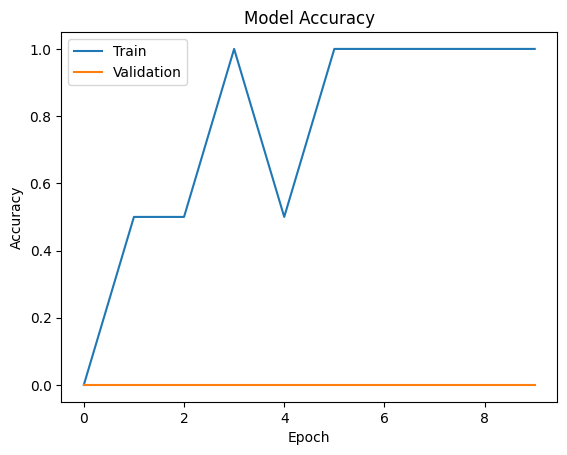

In [23]:
import matplotlib.pyplot as plt

# Grafik akurasi
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()

In [24]:
# Simpan model
model.save('model_font_cnn.h5')

print("Model berhasil disimpan")

Model berhasil disimpan


In [25]:
# Prediksi data test
prediksi = model.predict(X_test)

print(prediksi)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[2.4678366e-05 6.2376255e-01 3.7621284e-01]]
